# **1. Load the dataset and inspect structure**

### 1.1 Load the dataset

In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv('creditcard.csv')

### 1.2 Basic inspection

In [6]:
print(df.shape)                  # Rows, columns
print(df.dtypes)                 # Data types
print(df.isnull().sum())         # Missing values
print(df.duplicated().sum())     # Duplicates
print(df['Class'].value_counts()) # Class distribution

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
1081
Class
0    284315
1      

### 1.3: Remove Duplicates

In [7]:
df = df.drop_duplicates()
df.shape

(283726, 31)

In [8]:
# Drop the 'Time' column (not useful for modeling)
df.drop(columns=['Time'], inplace=True)

### Scale 'Amount' Column

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale 'Amount' column only
df['Amount'] = scaler.fit_transform(df[['Amount']])

### Split Features and Labels

In [10]:
# Features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Check shape
print(X.shape)  # Should be (283726, 29)
print(y.value_counts())  # Class 0 >> Class 1 (high imbalance)

(283726, 29)
Class
0    283253
1       473
Name: count, dtype: int64


### Save Scaler (for later use in API inference)

In [11]:
import joblib

joblib.dump(scaler, 'scaler_amount.pkl')

['scaler_amount.pkl']

# **Model Training: XGBoost with Threshold Tuning for Optimal AUPRC**

### Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

What does stratify=y do?

Ensures the train and test sets contain proportionally the same number of fraud and non-fraud cases as the original dataset.

Without this, due to class imbalance, your test set might contain very few or even zero fraud cases, which ruins evaluation.

### Train XGBoost Classifier

In [13]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # imbalance handling
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

### Predict Probabilities

In [ ]:
# Fit the model if not already fitted
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]  # Probabilities for class=1 (fraud)

c:\Users\suhas\envs\dl_all\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:21:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Plot Precision-Recall Curve & Find Best Threshold

AUPRC Score: 0.8129


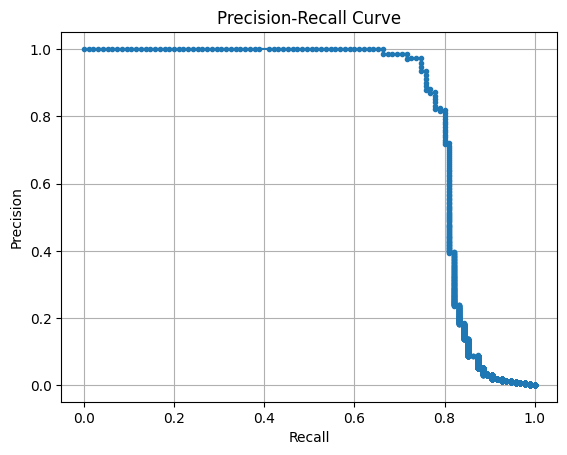

Best Threshold: 0.9567, F1: 0.8452


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
auprc_score = auc(recall, precision)
print(f"AUPRC Score: {auprc_score:.4f}")

# Plot
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

# Find best threshold (maximize F1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best Threshold: {best_threshold:.4f}, F1: {f1_scores[best_idx]:.4f}")

### Final Predictions & Metrics

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict using best threshold
y_pred = (y_probs >= best_threshold).astype(int)

# Evaluate
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)


Confusion Matrix:
 [[56649     2]
 [   24    71]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998     56651
           1     0.9726    0.7474    0.8452        95

    accuracy                         0.9995     56746
   macro avg     0.9861    0.8737    0.9225     56746
weighted avg     0.9995    0.9995    0.9995     56746



# **Save the Model & Create a Robust Prediction Pipeline** 

### Save the model and threshold

In [ ]:
import joblib

# Save model
joblib.dump(model, 'xgboost_model.pkl')

# Save threshold
with open("optimal_threshold.txt", "w") as f:
    f.write(str(best_threshold))  # e.g., 0.9567


### Create a modular prediction function

This will be called inside your microservice backend when a transaction comes in:

In [ ]:
import numpy as np
import joblib

# Load model
model = joblib.load('xgboost_model.pkl')

# Load threshold
with open("optimal_threshold.txt", "r") as f:
    THRESHOLD = float(f.read())

def predict_transaction(transaction_features: np.ndarray) -> dict:
    """
    Predict whether a single transaction is fraud or not.

    Args:
        transaction_features (np.ndarray): A 2D array of shape (1, n_features)

    Returns:
        dict: { "is_fraud": bool, "score": float }
    """
    score = model.decision_function(transaction_features)[0]
    is_fraud = score < THRESHOLD
    return {
        "is_fraud": is_fraud,
        "score": score
    }